In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load processed datasets

X_train = pd.read_csv("../artifacts/processed/X_train.csv")
X_test = pd.read_csv("../artifacts/processed/X_test.csv")

y_train = pd.read_csv("../artifacts/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../artifacts/processed/y_test.csv").squeeze()

In [3]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60800, 103)
X_test shape: (15200, 103)
y_train shape: (60800,)
y_test shape: (15200,)


In [4]:
print("\nMissing values:")
print("X_train:", X_train.isnull().sum().sum())
print("X_test :", X_test.isnull().sum().sum())

print("\nTarget missing values:")
print("y_train:", y_train.isnull().sum())
print("y_test :", y_test.isnull().sum())


Missing values:
X_train: 0
X_test : 0

Target missing values:
y_train: 0
y_test : 0


In [5]:
baseline_prediction = np.full(    # Create an array with the same number of values as y_test, and put the training mean in every position
    len(y_test),
    y_train.mean()
)

In [6]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_prediction
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_prediction
)

In [7]:
print("Baseline Model")
print("--------------------------")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²  :", baseline_r2)

Baseline Model
--------------------------
MAE : 35.42528021121884
RMSE: 44.373904387715555
R²  : -0.013079187196206377


### Define the Six Regression Models

In [8]:
# Linear Regression
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Decision Tree Regression
dt_model = DecisionTreeRegressor(
    random_state=42
)

# Random Forest Regression
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Gradient Boosting Regression
gb_model = GradientBoostingRegressor(
    random_state=42
)

# XGBoost Regression
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

# SVR
svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(
        kernel="rbf",
        C=10,
        epsilon=0.1
    ))
])

In [9]:
# Store all models
models = {
    "Linear Regression": linear_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model,
    "SVR": svr_model
}

In [14]:
# Train All Six Models
trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(
        X_train,
        y_train
    )

    trained_models[name] = model

print("\nAll models trained successfully.")

Training Linear Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training XGBoost...
Training SVR...

All models trained successfully.


In [15]:
# # Evaluate All Models
def evaluate_model(model, X, y):
    predictions = model.predict(X)
    mae = mean_absolute_error(
        y,
        predictions
    )
    rmse = np.sqrt(
        mean_squared_error(
            y,
            predictions
        )
    )
    r2 = r2_score(
        y,
        predictions
    )
    return mae, rmse, r2

In [16]:
results = []

for name, model in trained_models.items():

    mae, rmse, r2 = evaluate_model(
        model,
        X_test,
        y_test
    )

    results.append([
        name,
        mae,
        rmse,
        r2
    ])

In [17]:
# Comparison Table
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

results_df = results_df.sort_values(
    by="RMSE"
).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R2
0,Random Forest,11.648601,17.938464,0.834439
1,SVR,15.310495,21.711295,0.757473
2,Decision Tree,14.627500,23.651930,0.712180
3,XGBoost,21.134413,27.709499,0.604956
4,Gradient Boosting,22.887437,29.840799,0.541849
5,Linear Regression,24.785138,31.999270,0.473173


In [18]:
# Add Baseline to Comparison
baseline_row = pd.DataFrame({
    "Model": ["Baseline"],
    "MAE": [baseline_mae],
    "RMSE": [baseline_rmse],
    "R2": [baseline_r2]
})

results_with_baseline = pd.concat(
    [baseline_row, results_df],
    ignore_index=True
)

results_with_baseline

,Model,MAE,RMSE,R2
0,Baseline,35.425280,44.373904,-0.013079
1,Random Forest,11.648601,17.938464,0.834439
2,SVR,15.310495,21.711295,0.757473
3,Decision Tree,14.627500,23.651930,0.712180
4,XGBoost,21.134413,27.709499,0.604956
5,Gradient Boosting,22.887437,29.840799,0.541849
6,Linear Regression,24.785138,31.999270,0.473173


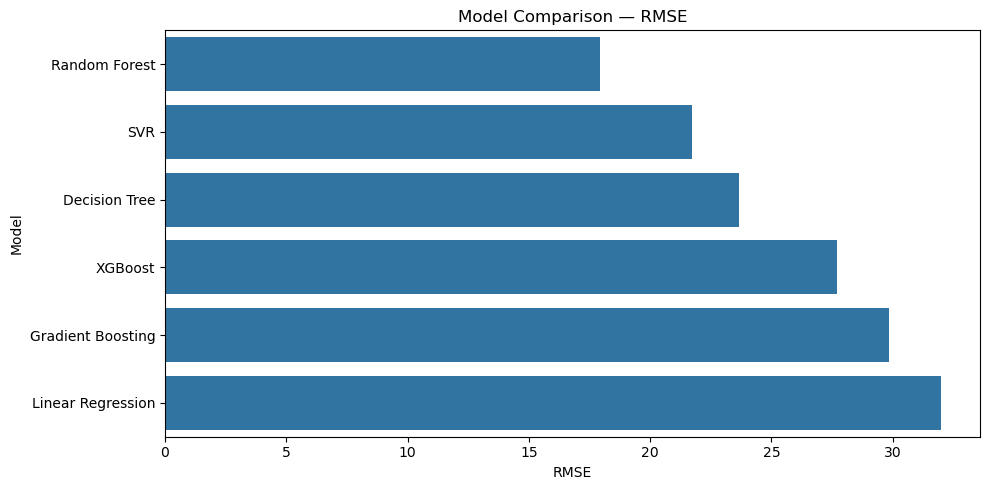

In [20]:
# Model Comparison — RMSE
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="RMSE",
    y="Model"
)

plt.title("Model Comparison — RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

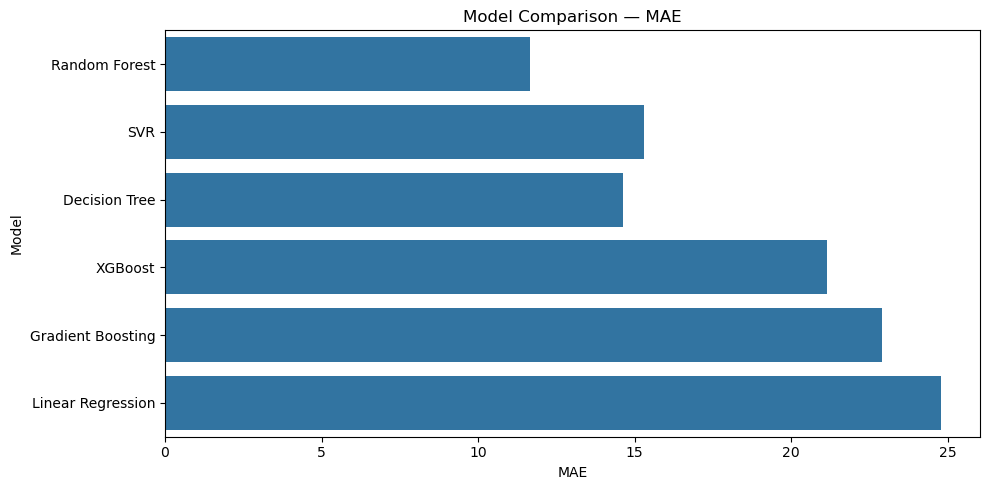

In [21]:
# Model Comparison — MAE
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="MAE",
    y="Model"
)

plt.title("Model Comparison — MAE")
plt.xlabel("MAE")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

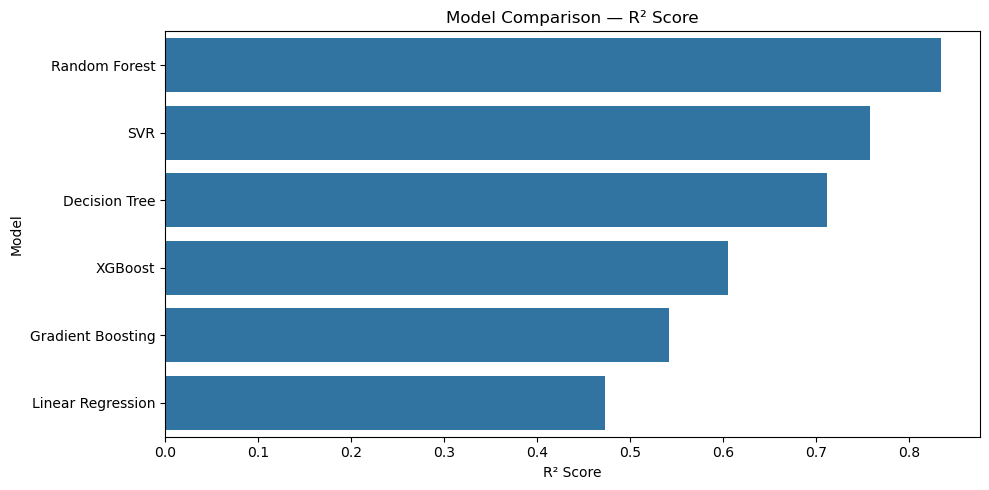

In [22]:
# Model Comparison — R²
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="R2",
    y="Model"
)

plt.title("Model Comparison — R² Score")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

In [24]:
# Select the Best Initial Model
best_model_name = results_df.iloc[0]["Model"]
print("Best initial model:", best_model_name)

Best initial model: Random Forest


In [25]:
best_model = trained_models[
    best_model_name
]
print(best_model)

RandomForestRegressor(n_jobs=-1, random_state=42)


In [26]:
# Actual vs Predicted Demand
best_predictions = best_model.predict(
    X_test
)

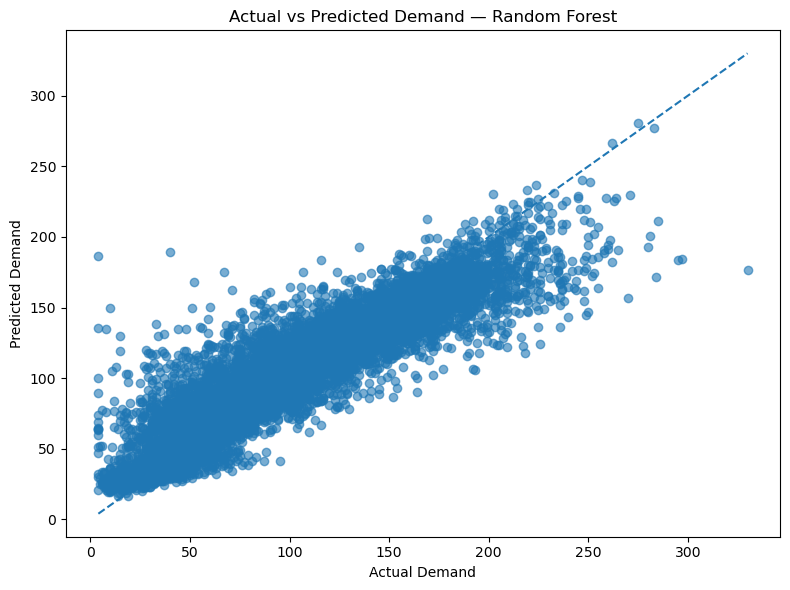

In [29]:
# Plot
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6
)

min_value = min(
    y_test.min(),
    best_predictions.min()
)

max_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title(
    f"Actual vs Predicted Demand — {best_model_name}"
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")

plt.tight_layout()
plt.show()

### Actual vs Predicted Demand — Random Forest

The Actual vs Predicted plot shows a strong positive relationship between actual and predicted demand, with most observations concentrated around the ideal diagonal line. This indicates that the Random Forest model captures the overall demand pattern effectively. However, some observations, particularly at higher demand levels, show larger deviations from the ideal line, suggesting that the model has difficulty predicting extreme demand values accurately. Further evaluation using RMSE, MAE, R², and residual analysis is required to determine the overall model performance.

In [30]:
# Residual Analysis
residuals = (
    y_test - best_predictions
)

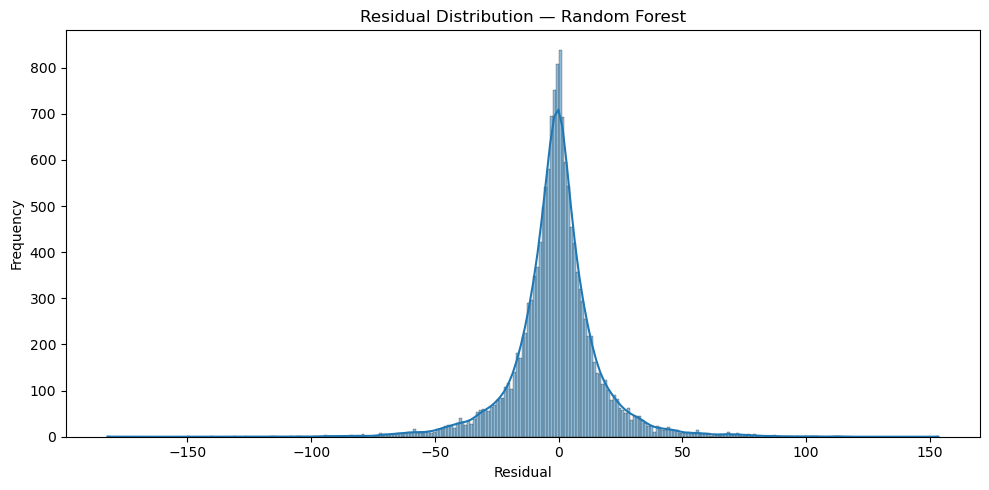

In [31]:
# Residual Distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    residuals,
    kde=True
)

plt.title(
    f"Residual Distribution — {best_model_name}"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Residual Distribution — Random Forest

- Most residuals are concentrated around **zero**, indicating that the model's predictions are generally close to the actual demand.
- The residual distribution is approximately centered around zero, suggesting **limited systematic prediction bias**.
- Some large positive and negative residuals are present, indicating that the model struggles with a small number of unusual demand observations.
- The distribution has noticeable tails and is not perfectly normal, which is acceptable for a **Random Forest regression model**.
- Overall, the residual analysis indicates that the Random Forest model provides **reasonably accurate and balanced predictions**, but some outlier cases may require further investigation.

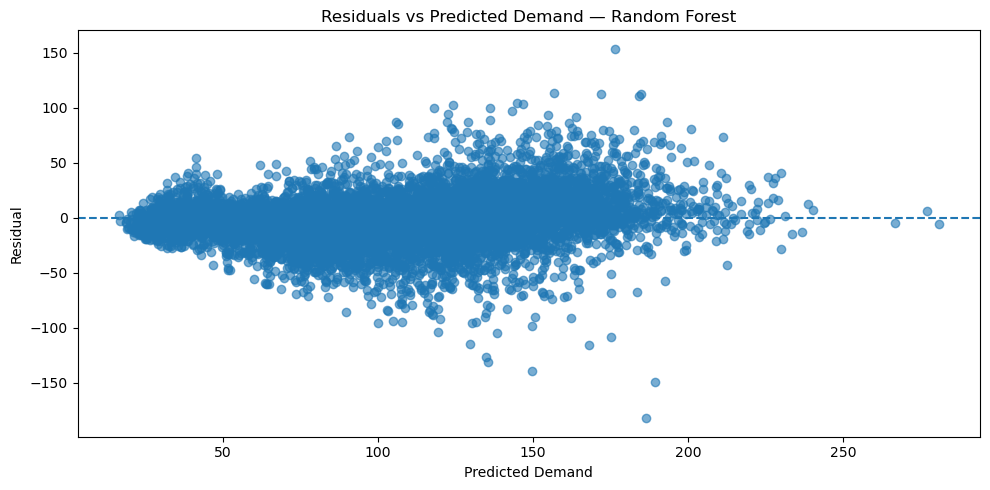

In [32]:
# Residuals vs Predicted
plt.figure(figsize=(10, 5))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    f"Residuals vs Predicted Demand — {best_model_name}"
)

plt.xlabel("Predicted Demand")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()

### Residuals vs Predicted Demand — Random Forest

- Most residuals are centered around **0**, indicating that the Random Forest model generally makes reasonable predictions.
- The residual spread increases as predicted demand moves toward the **100–180 range**, suggesting higher prediction uncertainty in this region.
- Several large positive and negative residuals are present, indicating some **outlier prediction errors**.
- The residuals are not perfectly evenly distributed around zero, suggesting **non-constant error variance**.
- Overall, the model captures the main demand patterns well, but its prediction accuracy decreases for certain demand ranges and extreme observations.

In [34]:
# Create the Random Forest model for tuning
rf_tuning_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [35]:
# Define a reasonable parameter grid
rf_param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [None, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.8]
}

In [36]:
# Use time-series cross-validation
tscv = TimeSeriesSplit(n_splits=3)

In [37]:
# Use RandomizedSearchCV
rf_search = RandomizedSearchCV(
    estimator=rf_tuning_model,
    param_distributions=rf_param_grid,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [38]:
# Train the tuning process
rf_search.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 15, 20],
                                        'max_features': ['sqrt', 0.8],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 150]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [39]:
# Find the best parameters
print("Best Random Forest Parameters:")
print(rf_search.best_params_)

Best Random Forest Parameters:
{'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': None}


In [40]:
print(
    "Best Cross-Validation RMSE:",
    -rf_search.best_score_
)

Best Cross-Validation RMSE: 27.727484601588042


In [41]:
# Get the tuned model
tuned_rf = rf_search.best_estimator_

In [42]:
# Prediction on test set
tuned_rf_predictions = tuned_rf.predict(
    X_test
)

In [43]:
# Evaluate the tuned model
tuned_rf_mae = mean_absolute_error(
    y_test,
    tuned_rf_predictions
)

tuned_rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_rf_predictions
    )
)

tuned_rf_r2 = r2_score(
    y_test,
    tuned_rf_predictions
)

print("Tuned Random Forest Performance")
print("--------------------------------")
print("MAE :", tuned_rf_mae)
print("RMSE:", tuned_rf_rmse)
print("R²  :", tuned_rf_r2)

Tuned Random Forest Performance
--------------------------------
MAE : 12.184742383658438
RMSE: 18.436386437170338
R²  : 0.8251201742220275


In [44]:
# Compare Original vs Tuned Random Forest
original_rf = results_df[
    results_df["Model"] == "Random Forest"
].iloc[0]

In [45]:
rf_comparison = pd.DataFrame({
    "Version": [
        "Original Random Forest",
        "Tuned Random Forest"
    ],
    
    "MAE": [
        original_rf["MAE"],
        tuned_rf_mae
    ],
    
    "RMSE": [
        original_rf["RMSE"],
        tuned_rf_rmse
    ],
    
    "R2": [
        original_rf["R2"],
        tuned_rf_r2
    ]
})

rf_comparison

,Version,MAE,RMSE,R2
0,Original Random Forest,11.648601,17.938464,0.834439
1,Tuned Random Forest,12.184742,18.436386,0.825120


In [46]:
# Save the final Random Forest
final_model = trained_models["Random Forest"]

joblib.dump(
    final_model,
    "final_demand_model.pkl"
)

['final_demand_model.pkl']

In [47]:
print("Final model saved successfully.")

Final model saved successfully.
